# 2D DC charge transport with nextnano++

This tutorial solves the charge transport of the InP-based InGaAsP modulator
cross-section on a *full 2D* domain using `ChargeSimulatorNN2D`.

Unlike the `dc_electro_optical` tutorial - which solves a 1D Poisson-drift-
diffusion problem along a vertical line with `ChargeSimulatorSolcore` - here we
hand nextnano++ a 2D `simulation_window` polygon and let it resolve the true
(Ex, Ey) field and carrier distribution over the whole cross-section, including
the lateral current path from the top p-contact to the side n-contact.

## Requirements

* nextnano++ installed and configured (see `imodulator.Config`).
* The `imodulator` environment active as the notebook kernel.


In [1]:
from pathlib import Path

import numpy as np
import shapely
import matplotlib.pyplot as plt

import imodulator
from imodulator.ChargeSimulator import ChargeSimulatorNN2D, nn

# Send nextnano++ output to this notebook's directory (the kernel starts here).
notebook_dir = Path.cwd()
nn.config.set("nextnano++", "outputdirectory", str(notebook_dir))

Successfully imported lumapi


c:\Users\20235351\AppData\Local\anaconda3\envs\imodulator\lib\site-packages\solcore\registries.py:73: UserWarning: Optics solver 'RCWA' will not be available. An installation of S4 has not been found.
  warn(


Successfully imported nextnanopy
Successfully configured nextnano++ settings


c:\Users\20235351\AppData\Local\anaconda3\envs\imodulator\lib\site-packages\nextnanopy-0.1.22-py3.10.egg\nextnanopy\defaults.py:202: UserWarning: Unsupported products in config file: ['nextnano.NEGF++'] will be ignored. To not see this message, please remove unsupported products from the config file: C:\Users\20235351\.nextnanopy-configNote: nextnano.NEGF++ was renamed to nextnano.NEGF, nextnano.NEGF was renamed to nextnano.NEGF_classic. Please check the documentation for more details.


In [9]:
nn.config

NNConfig(C:\Users\20235351\.nextnanopy-config)
[nextnano++]
exe = D:/nextnano/2026_02_05/nextnano++/bin/nextnano++_Intel_64bit.exe
license = D:/nextnano/2026_02_05/License/License_nnp.lic
database = D:/nextnano/2026_02_05/nextnano++/database/database.nnp
outputdirectory = d:\Repos\Imodulator\docs\Tutorials\charge_simulation_nn
threads = 0
[nextnano3]
exe = 
license = 
database = 
threads = 0
outputdirectory = 
debuglevel = 0
cancel = -1
softkill = -1
[nextnano.NEGF]
exe = 
license = 
database = 
outputdirectory = 
threads = 0
[nextnano.NEGF++]
exe = 
license = 
database = 
outputdirectory = 
threads = 0
[nextnano.MSB]
exe = 
license = 
database = 
outputdirectory = 
threads = 0
[nextnano.NEGF_classic]
exe = 
license = 
database = 
outputdirectory = 
threads = 0
[nextnanoevo]
license = 

## Device geometry (all dimensions in um)

Vertical p-i-n stack, from bottom to top: n / wg1 / wg2 / p1 / p2.
The signal metal sits on top (biased p-contact); a ground metal sits on the
n-layer to the left, so current flows down the stack and laterally through n.

In [2]:
w_wg = 1.0            # stack width
h_n = 0.4
h_wg1 = 0.5
h_wg2 = 0.3
h_p1 = 1.0
h_p2 = 0.2

w_sig_metal = 5.0     # signal (p) metal width
metal_sep = 10.0      # gap between signal and ground metals
w_gnd_metal = 10.0    # ground (n) metal width
h_metal = 4.0

# cumulative y of each stack interface
y_n0 = 0.0
y_n1 = y_n0 + h_n
y_wg1 = y_n1 + h_wg1
y_wg2 = y_wg1 + h_wg2
y_p1 = y_wg2 + h_p1
y_p2 = y_p1 + h_p2      # top of the semiconductor stack

# n-layer spans the full width so the side contact can reach it
x_n_edge = w_sig_metal / 2 + metal_sep + w_gnd_metal

## nextnano charge kwargs per region

`material_definition` defaults to `"Ga(x)In(1-x)As(y)P(1-y)"`; `alloy_x` is the
InP-lattice-matched Ga fraction for the given As fraction `alloy_y`.

| `alloy_y` | material | `alloy_x` |
| --- | --- | --- |
| 0.00 | InP | 0.000 |
| 0.53 | Q1.3 InGaAsP | 0.245 |
| 1.00 | Ga0.47In0.53As | 0.468 |

In [3]:
def charge_kwargs(alloy_x, alloy_y, doping_type, doping_conc):
    return {
        "material_definition": None,
        "alloy_x": alloy_x,
        "alloy_y": alloy_y,
        "doping_type": doping_type,
        "doping_conc": doping_conc,
    }

In [4]:
n = imodulator.SemiconductorPolygon(
    shapely.box(-x_n_edge, y_n0, x_n_edge, y_n1),
    name="n",
    charge_mesh_settings={"resolution": 0.003},
    charge_transport_simulator_kwargs=charge_kwargs(0.0, 0.0, "n", 1e18),
)

wg1 = imodulator.SemiconductorPolygon(
    shapely.box(-w_wg / 2, y_n1, w_wg / 2, y_wg1),
    name="wg1",
    charge_mesh_settings={"resolution": 0.002},
    charge_transport_simulator_kwargs=charge_kwargs(0.245, 0.53, "n", 1e16),
)

wg2 = imodulator.SemiconductorPolygon(
    shapely.box(-w_wg / 2, y_wg1, w_wg / 2, y_wg2),
    name="wg2",
    charge_mesh_settings={"resolution": 0.002},
    charge_transport_simulator_kwargs=charge_kwargs(0.0, 0.0, "n", 1e16),
)

p1 = imodulator.SemiconductorPolygon(
    shapely.box(-w_wg / 2, y_wg2, w_wg / 2, y_p1),
    name="p1",
    charge_mesh_settings={"resolution": 0.003},
    charge_transport_simulator_kwargs=charge_kwargs(0.0, 0.0, "p", 1e17),
)

p2 = imodulator.SemiconductorPolygon(
    shapely.box(-w_wg / 2, y_p1, w_wg / 2, y_p2),
    name="p2",
    charge_mesh_settings={"resolution": 0.003},
    charge_transport_simulator_kwargs=charge_kwargs(0.468, 1.0, "p", 1e19),
)

The first `MetalPolygon` in the device becomes `contact1` (biased), the second
`contact2` (grounded). We list the signal (p) metal first, ground (n) metal
second.

In [5]:
sig_metal = imodulator.MetalPolygon(
    shapely.box(-w_sig_metal / 2, y_p2, w_sig_metal / 2, y_p2 + h_metal),
    name="sig_metal",
)

n_metal_left = imodulator.MetalPolygon(
    shapely.box(-x_n_edge, y_n1, -(w_sig_metal / 2 + metal_sep), y_n1 + h_metal),
    name="n_metal_left",
)

device = imodulator.PhotonicDevice(
    [sig_metal, n_metal_left, p2, p1, wg2, wg1, n]
)

## 2D charge transport simulation

The window captures the vertical junction, the signal metal, and the side
ground contact - but stops short of the (absent) right metal.

In [12]:
window = shapely.box(-(x_n_edge + 0.5), -0.05, w_sig_metal / 2 + 0.5, y_p2 + h_metal + 0.1)

charge2d = ChargeSimulatorNN2D(
    device=device,
    output_directory=str(notebook_dir),
    simulation_window=window,
    bias_start_stop_step=[0, 5, 11],
)

Charge transport regions:
p2
p1
wg2
wg1
n
Contacts: ['sig_metal', 'n_metal_left']
  contact1 (biased) = sig_metal
  contact2 (ground) = n_metal_left
Input file created: d:\Repos\Imodulator\docs\Tutorials\charge_simulation_nn\quicksave2d.in


Inspect the geometry and detected contacts before running.

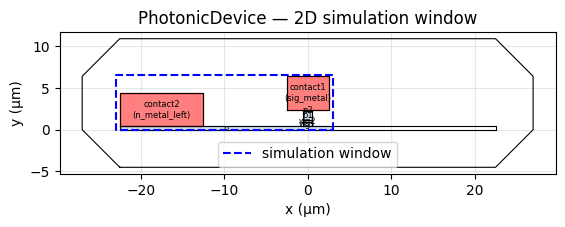

In [7]:
charge2d.plot_with_window(fill_polygons=False)
plt.show()

Run nextnano++ and load the 2D results.

In [14]:
charge2d.NNinputf.execute(show_log=True)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
D:/nextnano/2026_02_05/nextnano++/bin/nextnano++_Intel_64bit.exe --license D:/nextnano/2026_02_05/License/License_nnp.lic --database D:/nextnano/2026_02_05/nextnano++/database/database.nnp --threads 0 --outputdirectory d:\Repos\Imodulator\docs\Tutorials\charge_simulation_nn\quicksave2d --noautooutdir d:\Repos\Imodulator\docs\Tutorials\charge_simulation_nn\quicksave2d.in 

nextnano++ 2.4.27 from 2025-12-11 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                                                             
The terms of copyright of the nextnano++ code and of third party source codes
and libraries used in the nextnano++ code can be found in the fi

{'process': <Popen: returncode: 4294967295 args: '"D:/nextnano/2026_02_05/nextnano++/bin...>,
 'outputdirectory': 'd:\\Repos\\Imodulator\\docs\\Tutorials\\charge_simulation_nn\\quicksave2d',
 'filename': 'quicksave2d',
 'logfile': 'd:\\Repos\\Imodulator\\docs\\Tutorials\\charge_simulation_nn\\quicksave2d\\quicksave2d.log',
 'cmd': '"D:/nextnano/2026_02_05/nextnano++/bin/nextnano++_Intel_64bit.exe" --license "D:/nextnano/2026_02_05/License/License_nnp.lic" --database "D:/nextnano/2026_02_05/nextnano++/database/database.nnp" --threads 0 --outputdirectory "d:\\Repos\\Imodulator\\docs\\Tutorials\\charge_simulation_nn\\quicksave2d" --noautooutdir "d:\\Repos\\Imodulator\\docs\\Tutorials\\charge_simulation_nn\\quicksave2d.in"',
 'wdir': 'D:/nextnano/2026_02_05/nextnano++/bin',
 'queue': <queue.Queue at 0x18029884850>,
 'tout': <Thread(Thread-17 (read_output), stopped 6224)>,
 'terr': <Thread(Thread-18 (read_output), stopped 25876)>}

In [ ]:
charge2d.load_output_data()

Colour-map a couple of quantities across the bias sweep.

In [ ]:
charge2d.plot_results(V_idx=[0, len(charge2d.V) - 1], quantity="N")
charge2d.plot_results(V_idx=[0, len(charge2d.V) - 1], quantity="Ey")
plt.show()

Transfer the interpolated 2D fields onto `device.charge` for the EO stage.

In [ ]:
charge2d.transfer_results_to_device()

print("device.charge keys:", list(device.charge.keys()))
print("bias points:", np.asarray(device.charge["V"]))